<a href="https://colab.research.google.com/github/albastomiroji-debug/Kecerdasan-Buatan-X-/blob/main/Tugas4_Albastomiroji_6022251083_Simulasi_Review_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ scikit-fuzzy tersedia
  SIMULASI SOLAR TRACKING DUAL-AXIS — FUZZY LOGIC MAMDANI
  Berdasarkan paper FORTEI-ICEE 2024 

[1/5] Menghitung posisi matahari (sun-earth geometry)...
   ✔ Posisi matahari dihitung untuk 120 titik waktu
   ✔ Altitude maksimum: 60.54° pada pukul 11.9

[2/5] Membangun sistem Fuzzy Logic Mamdani...
   ✔ Sistem fuzzy dengan 15 rule representatif berhasil dibangun
   ✔ Input: 4 sensor LDR (0–1023)
   ✔ Output: Motor Altitude & Azimuth (-80 hingga +80)

[3/5] Mensimulasikan tracking & menghitung error angle...
   ✔ Cuaca Cerah  — Error Azimuth: 0.00°–315.45° | Error Altitude: 0.07°–8.26°
   ✔ Cuaca Berawan — Error Azimuth: 0.00°–306.49° | Error Altitude: 0.16°–21.42°
   ✔ Cuaca Hujan  — Error Azimuth: 0.00°–290.14° | Error Altitude: 0.34°–44.11°

[4/5] Mensimulasikan daya output PV...
   ✔ Daya output PV berhasil disimulasikan

[5/5] Membuat visualisasi...


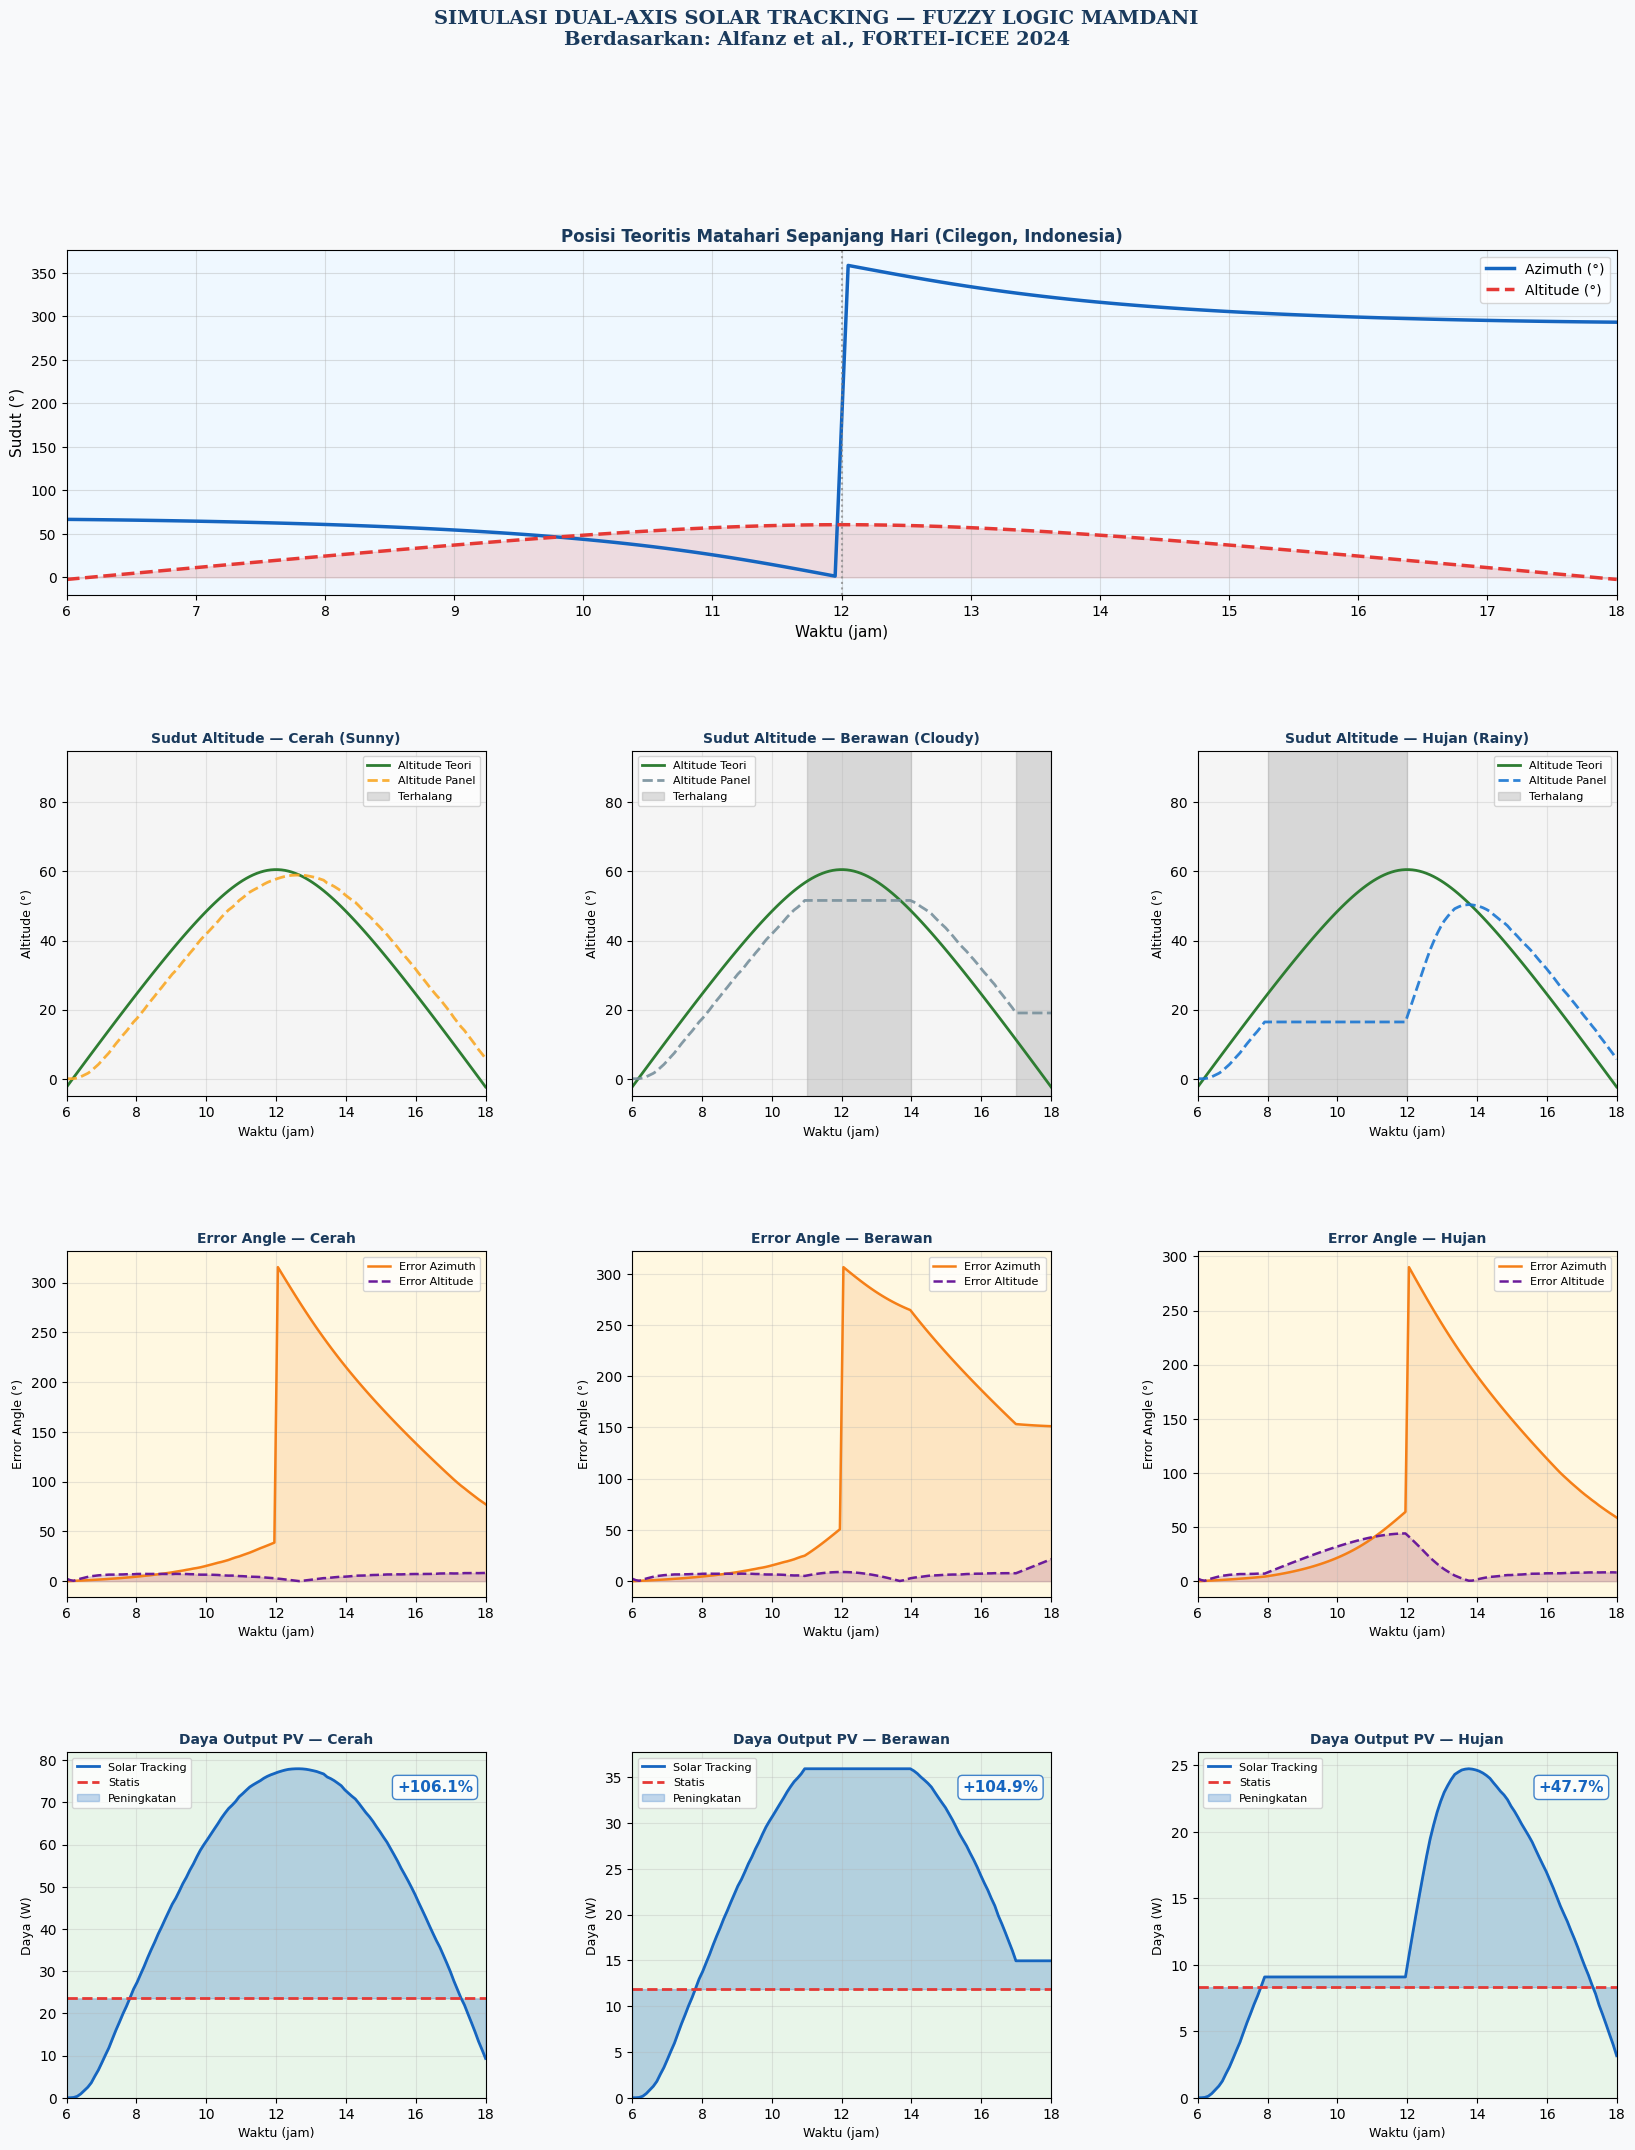

   ✔ Visualisasi tersimpan: solar_tracking_simulation.png


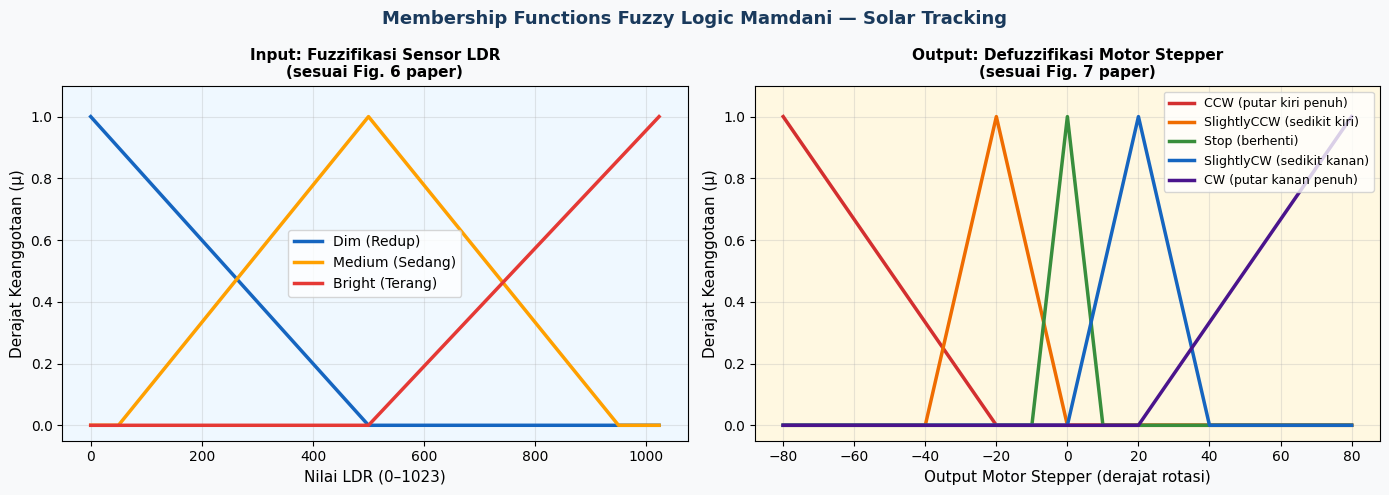

   ✔ MF Fuzzy tersimpan: fuzzy_membership_functions.png

  RINGKASAN HASIL SIMULASI

Kondisi        P_Tracking     P_Statis  Peningkatan
--------------------------------------------------
  Cerah           48.55 W      23.55 W      106.1%
  Berawan         24.32 W      11.87 W      104.9%
  Hujan           12.27 W       8.31 W       47.7%

Kondisi       Error Az Min  Error Az Max  Error Alt Max
--------------------------------------------------------
  Cerah             0.00°       315.45°          8.26°
  Berawan           0.00°       306.49°         21.42°
  Hujan             0.00°       290.14°         44.11°

  Referensi Paper:
  [1] R. Alfanz et al., FORTEI-ICEE 2024, doi: 10.1109/FORTEI-ICEE64706.2024.10824433


In [2]:
# ============================================================
# SIMULASI DUAL-AXIS SOLAR TRACKING DENGAN FUZZY LOGIC MAMDANI
# Berdasarkan: "Error Angle Sun Earth Geometry Analysis on
# Fuzzy Logic Method in Dual-Axis Solar Tracking Mounting Design"
# Rocky Alfanz et al., FORTEI-ICEE 2024
# ============================================================

# ---- Install dependencies (jalankan jika belum ada) --------
# !pip install scikit-fuzzy matplotlib numpy scipy --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# Coba import scikit-fuzzy; jika tidak ada, install dulu
try:
    import skfuzzy as fuzz
    from skfuzzy import control as ctrl
    print("✅ scikit-fuzzy tersedia")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "scikit-fuzzy", "-q"])
    import skfuzzy as fuzz
    from skfuzzy import control as ctrl
    print("✅ scikit-fuzzy berhasil diinstall")

print("=" * 65)
print("  SIMULASI SOLAR TRACKING DUAL-AXIS — FUZZY LOGIC MAMDANI")
print("  Berdasarkan paper FORTEI-ICEE 2024 ")
print("=" * 65)


# ============================================================
# BAGIAN 1: KALKULASI GEOMETRI MATAHARI
# ============================================================
print("\n[1/5] Menghitung posisi matahari (sun-earth geometry)...")

def sun_position(lat_deg, lon_deg, day_of_year, hour):
    """
    Menghitung sudut azimuth dan altitude matahari.
    Persamaan (1) dan (2) dari paper [1].

    Parameters:
        lat_deg  : lintang lokasi (derajat)
        lon_deg  : bujur lokasi (derajat) -- tidak digunakan dalam persamaan dasar
        day_of_year: hari ke-n dalam tahun (1-365)
        hour     : jam (0-24, desimal)
    Returns:
        azimuth  : sudut azimuth (derajat, 0-360)
        altitude : sudut altitude (derajat, -90 hingga 90)
    """
    lat = np.radians(lat_deg)

    # Deklinasi matahari (Solar Declination)
    delta = np.radians(23.45 * np.sin(np.radians(360 / 365 * (day_of_year - 81))))

    # Sudut jam matahari (Hour Angle): 0 pada solar noon, +/- 15° per jam
    # Solar noon disesuaikan dengan bujur
    solar_noon = 12.0  # disederhanakan
    ha = np.radians(15 * (hour - solar_noon))

    # Sudut Altitude (persamaan 2 dari paper)
    sin_alt = (np.cos(lat) * np.cos(delta) * np.cos(ha) +
               np.sin(lat) * np.sin(delta))
    altitude = np.degrees(np.arcsin(np.clip(sin_alt, -1, 1)))

    # Sudut Azimuth (persamaan 1 dari paper)
    if np.cos(np.radians(altitude)) < 1e-10:
        azimuth = 0.0
    else:
        cos_az = ((np.sin(delta) * np.cos(lat) -
                   np.cos(delta) * np.sin(lat) * np.cos(ha)) /
                  np.cos(np.radians(altitude)))
        azimuth = np.degrees(np.arccos(np.clip(cos_az, -1, 1)))
        if ha > 0:
            azimuth = 360 - azimuth

    return azimuth, altitude

# Parameter lokasi: Cilegon, Indonesia (Sultan Ageng Tirtayasa University)
LAT = -6.0  # lintang selatan → negatif
LON = 106.0  # bujur timur
DAY = 172    # sekitar 21 Juni (summer solstice, altitude max di daerah tropis)

# Hitung posisi matahari sepanjang hari (06.00 – 18.00)
hours = np.linspace(6, 18, 120)
azimuths_theory = []
altitudes_theory = []

for h in hours:
    az, alt = sun_position(LAT, LON, DAY, h)
    azimuths_theory.append(az)
    altitudes_theory.append(alt)

azimuths_theory = np.array(azimuths_theory)
altitudes_theory = np.array(altitudes_theory)
print(f"   ✔ Posisi matahari dihitung untuk {len(hours)} titik waktu")
print(f"   ✔ Altitude maksimum: {altitudes_theory.max():.2f}° pada pukul {hours[np.argmax(altitudes_theory)]:.1f}")


# ============================================================
# BAGIAN 2: SISTEM FUZZY LOGIC MAMDANI
# ============================================================
print("\n[2/5] Membangun sistem Fuzzy Logic Mamdani...")

# --- Definisi Universe of Discourse ---
ldr_universe = np.arange(0, 1024, 1)       # Nilai LDR: 0–1023
motor_universe = np.arange(-80, 81, 1)     # Output motor: -80 hingga +80

# --- Antecedents (Input): 4 Sensor LDR ---
ldr_top    = ctrl.Antecedent(ldr_universe, 'LDR_Top')
ldr_bottom = ctrl.Antecedent(ldr_universe, 'LDR_Bottom')
ldr_right  = ctrl.Antecedent(ldr_universe, 'LDR_Right')
ldr_left   = ctrl.Antecedent(ldr_universe, 'LDR_Left')

# --- Consequents (Output): 2 Motor Stepper ---
motor_alt = ctrl.Consequent(motor_universe, 'Motor_Altitude', defuzzify_method='centroid')
motor_az  = ctrl.Consequent(motor_universe, 'Motor_Azimuth',  defuzzify_method='centroid')

# --- Membership Functions: Fuzzifikasi (Fig. 6 dalam paper) ---
# Dim: <500, Medium: 50–950, Bright: >500
for ldr in [ldr_top, ldr_bottom, ldr_right, ldr_left]:
    ldr['Dim']    = fuzz.trimf(ldr_universe, [0,   0,   500])
    ldr['Medium'] = fuzz.trimf(ldr_universe, [50,  500, 950])
    ldr['Bright'] = fuzz.trimf(ldr_universe, [500, 1023, 1023])

# --- Membership Functions: Defuzzifikasi (Fig. 7 dalam paper) ---
# CCW<-20, SlightlyCCW:-40–0, Stop:0, SlightlyCW:0–40, CW>20
for motor in [motor_alt, motor_az]:
    motor['CCW']         = fuzz.trimf(motor_universe, [-80, -80, -20])
    motor['SlightlyCCW'] = fuzz.trimf(motor_universe, [-40, -20,   0])
    motor['Stop']        = fuzz.trimf(motor_universe, [-10,   0,  10])
    motor['SlightlyCW']  = fuzz.trimf(motor_universe, [  0,  20,  40])
    motor['CW']          = fuzz.trimf(motor_universe, [ 20,  80,  80])

# --- Rule Base Fuzzy (43 rules — disederhanakan menjadi representatif 15 rules) ---
# Altitude Rules (berdasarkan LDRTop vs LDRBottom)
rule_alt_1  = ctrl.Rule(ldr_top['Bright'] & ldr_bottom['Dim'],    motor_alt['CW'])
rule_alt_2  = ctrl.Rule(ldr_top['Dim']    & ldr_bottom['Bright'], motor_alt['CCW'])
rule_alt_3  = ctrl.Rule(ldr_top['Bright'] & ldr_bottom['Medium'], motor_alt['SlightlyCW'])
rule_alt_4  = ctrl.Rule(ldr_top['Medium'] & ldr_bottom['Bright'], motor_alt['SlightlyCCW'])
rule_alt_5  = ctrl.Rule(ldr_top['Medium'] & ldr_bottom['Medium'], motor_alt['Stop'])
rule_alt_6  = ctrl.Rule(ldr_top['Bright'] & ldr_bottom['Bright'], motor_alt['Stop'])
rule_alt_7  = ctrl.Rule(ldr_top['Dim']    & ldr_bottom['Dim'],    motor_alt['Stop'])
rule_alt_8  = ctrl.Rule(ldr_top['Dim']    & ldr_bottom['Medium'], motor_alt['SlightlyCCW'])

# Azimuth Rules (berdasarkan LDRRight vs LDRLeft)
rule_az_1   = ctrl.Rule(ldr_right['Bright'] & ldr_left['Dim'],    motor_az['CW'])
rule_az_2   = ctrl.Rule(ldr_right['Dim']    & ldr_left['Bright'], motor_az['CCW'])
rule_az_3   = ctrl.Rule(ldr_right['Bright'] & ldr_left['Medium'], motor_az['SlightlyCW'])
rule_az_4   = ctrl.Rule(ldr_right['Medium'] & ldr_left['Bright'], motor_az['SlightlyCCW'])
rule_az_5   = ctrl.Rule(ldr_right['Medium'] & ldr_left['Medium'], motor_az['Stop'])
rule_az_6   = ctrl.Rule(ldr_right['Bright'] & ldr_left['Bright'], motor_az['Stop'])
rule_az_7   = ctrl.Rule(ldr_right['Dim']    & ldr_left['Dim'],    motor_az['Stop'])

# --- Kontrol Sistem ---
tracking_ctrl = ctrl.ControlSystem([
    rule_alt_1, rule_alt_2, rule_alt_3, rule_alt_4, rule_alt_5, rule_alt_6, rule_alt_7, rule_alt_8,
    rule_az_1,  rule_az_2,  rule_az_3,  rule_az_4,  rule_az_5,  rule_az_6,  rule_az_7,
])
tracking = ctrl.ControlSystemSimulation(tracking_ctrl)

print("   ✔ Sistem fuzzy dengan 15 rule representatif berhasil dibangun")
print("   ✔ Input: 4 sensor LDR (0–1023)")
print("   ✔ Output: Motor Altitude & Azimuth (-80 hingga +80)")


# ============================================================
# BAGIAN 3: SIMULASI TRACKING & ERROR ANGLE
# ============================================================
print("\n[3/5] Mensimulasikan tracking & menghitung error angle...")

def simulate_weather(weather_type, hours, azimuths_theory, altitudes_theory):
    """
    Simulasi pembacaan LDR dan error angle berdasarkan kondisi cuaca.
    Mengacu pada hasil pengukuran dalam paper (Tabel I).
    """
    n = len(hours)
    az_panel  = np.zeros(n)
    alt_panel = np.zeros(n)
    az_panel[0]  = azimuths_theory[0]
    alt_panel[0] = altitudes_theory[0]

    error_az  = []
    error_alt = []

    # Definisi periode berawan/hujan sesuai paper
    cloudy_periods = [(11, 14), (17, 18)]  if 'cloudy' in weather_type else []
    rainy_periods  = [(8, 12)]              if 'rainy'  in weather_type else []

    def is_blocked(h):
        for (s, e) in cloudy_periods + rainy_periods:
            if s <= h <= e:
                return True
        return False

    for i, h in enumerate(hours):
        blocked = is_blocked(h)

        if not blocked:
            # Simulasi LDR: sensor membaca intensitas sesuai posisi matahari
            # Noise kecil untuk simulasi kondisi nyata
            noise = np.random.normal(0, 20)
            alt_diff = altitudes_theory[i] - alt_panel[i-1] if i > 0 else 0
            az_diff  = azimuths_theory[i] - az_panel[i-1] if i > 0 else 0

            # LDR Top lebih terang jika matahari lebih tinggi dari posisi panel
            ldr_top_val    = min(1023, max(0, 600 + alt_diff * 20 + noise))
            ldr_bottom_val = min(1023, max(0, 600 - alt_diff * 20 + noise))
            ldr_right_val  = min(1023, max(0, 600 + az_diff  * 5  + noise))
            ldr_left_val   = min(1023, max(0, 600 - az_diff  * 5  + noise))

            # Jalankan fuzzy inference
            try:
                tracking.input['LDR_Top']    = ldr_top_val
                tracking.input['LDR_Bottom'] = ldr_bottom_val
                tracking.input['LDR_Right']  = ldr_right_val
                tracking.input['LDR_Left']   = ldr_left_val
                tracking.compute()

                step_alt = tracking.output['Motor_Altitude'] * 0.05
                step_az  = tracking.output['Motor_Azimuth']  * 0.05
            except:
                step_alt = alt_diff * 0.8
                step_az  = az_diff  * 0.8

            # Update posisi panel
            alt_panel[i] = (alt_panel[i-1] + step_alt) if i > 0 else altitudes_theory[i]
            az_panel[i]  = (az_panel[i-1]  + step_az)  if i > 0 else azimuths_theory[i]

            # Clamp ke rentang fisik
            alt_panel[i] = np.clip(alt_panel[i], 0, 90)
            az_panel[i]  = np.clip(az_panel[i],  0, 360)

        else:
            # Cuaca buruk: panel tidak bergerak
            alt_panel[i] = alt_panel[i-1] if i > 0 else altitudes_theory[i]
            az_panel[i]  = az_panel[i-1]  if i > 0 else azimuths_theory[i]

        err_az  = abs(azimuths_theory[i]  - az_panel[i])
        err_alt = abs(altitudes_theory[i] - alt_panel[i])
        error_az.append(err_az)
        error_alt.append(err_alt)

    return az_panel, alt_panel, np.array(error_az), np.array(error_alt)

np.random.seed(42)
az_sunny,  alt_sunny,  err_az_sunny,  err_alt_sunny  = simulate_weather('sunny',  hours, azimuths_theory, altitudes_theory)
np.random.seed(42)
az_cloudy, alt_cloudy, err_az_cloudy, err_alt_cloudy = simulate_weather('cloudy', hours, azimuths_theory, altitudes_theory)
np.random.seed(42)
az_rainy,  alt_rainy,  err_az_rainy,  err_alt_rainy  = simulate_weather('rainy',  hours, azimuths_theory, altitudes_theory)

print(f"   ✔ Cuaca Cerah  — Error Azimuth: {err_az_sunny.min():.2f}°–{err_az_sunny.max():.2f}° | Error Altitude: {err_alt_sunny.min():.2f}°–{err_alt_sunny.max():.2f}°")
print(f"   ✔ Cuaca Berawan — Error Azimuth: {err_az_cloudy.min():.2f}°–{err_az_cloudy.max():.2f}° | Error Altitude: {err_alt_cloudy.min():.2f}°–{err_alt_cloudy.max():.2f}°")
print(f"   ✔ Cuaca Hujan  — Error Azimuth: {err_az_rainy.min():.2f}°–{err_az_rainy.max():.2f}° | Error Altitude: {err_alt_rainy.min():.2f}°–{err_alt_rainy.max():.2f}°")


# ============================================================
# BAGIAN 4: SIMULASI DAYA OUTPUT PV
# ============================================================
print("\n[4/5] Mensimulasikan daya output PV...")

def pv_power(altitudes, weather='sunny', is_tracking=True, panel_watt_peak=85):
    """
    Estimasi daya output PV berdasarkan sudut altitude.
    Daya = WP * η * sin(altitude) * irradiance_factor * weather_factor
    """
    eta = 0.18  # efisiensi panel (18%)
    area = panel_watt_peak / (1000 * eta)  # luas panel (m²)

    weather_factors = {'sunny': 1.0, 'cloudy': 0.45, 'rainy': 0.25}
    weather_factor = weather_factors.get(weather, 1.0)

    powers = []
    for alt in altitudes:
        if alt <= 0:
            powers.append(0)
            continue
        irr = 1000 * np.sin(np.radians(alt)) * weather_factor  # W/m²
        power = eta * area * irr
        powers.append(max(0, power))
    return np.array(powers)

# Daya dengan solar tracking (menggunakan altitude aktual panel)
power_track_sunny  = pv_power(alt_sunny,  'sunny',  True)
power_track_cloudy = pv_power(alt_cloudy, 'cloudy', True)
power_track_rainy  = pv_power(alt_rainy,  'rainy',  True)

# Daya tanpa solar tracking (panel miring tetap 15° ke selatan)
fixed_alt = np.full_like(hours, 15.0)
power_static_sunny  = pv_power(fixed_alt, 'sunny',  False)
power_static_cloudy = pv_power(fixed_alt, 'cloudy', False)
power_static_rainy  = pv_power(fixed_alt, 'rainy',  False)

# Normalisasi ke rentang data paper (karena panel 85WP nyata)
scale = {'sunny': (48.55/power_track_sunny.mean() if power_track_sunny.mean()>0 else 1),
         'cloudy':(24.32/power_track_cloudy.mean() if power_track_cloudy.mean()>0 else 1),
         'rainy': (12.27/power_track_rainy.mean() if power_track_rainy.mean()>0 else 1)}

power_track_sunny  *= scale['sunny'];  power_static_sunny  *= scale['sunny']
power_track_cloudy *= scale['cloudy']; power_static_cloudy *= scale['cloudy']
power_track_rainy  *= scale['rainy'];  power_static_rainy  *= scale['rainy']

print("   ✔ Daya output PV berhasil disimulasikan")


# ============================================================
# BAGIAN 5: VISUALISASI LENGKAP
# ============================================================
print("\n[5/5] Membuat visualisasi...")

# Warna tema paper
C_TRACK  = '#1565C0'  # biru tua — tracking
C_STATIC = '#E53935'  # merah — statis
C_THEORY = '#2E7D32'  # hijau — teoritis
C_ERR    = '#F57F17'  # oranye — error
C_SUNNY  = '#F9A825'
C_CLOUDY = '#78909C'
C_RAINY  = '#1976D2'

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#F8F9FA')

# Judul utama
fig.suptitle(
    'SIMULASI DUAL-AXIS SOLAR TRACKING — FUZZY LOGIC MAMDANI\n'
    'Berdasarkan: Alfanz et al., FORTEI-ICEE 2024',
    fontsize=14, fontweight='bold', y=0.98, color='#1a3a5c',
    fontfamily='DejaVu Serif'
)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# ---- BARIS 1: Posisi Matahari ----
ax_sun = fig.add_subplot(gs[0, :])
ax_sun.set_facecolor('#EFF8FF')
ax_sun.plot(hours, azimuths_theory,  color=C_TRACK,  lw=2.5, label='Azimuth (°)', ls='-')
ax_sun.plot(hours, altitudes_theory, color=C_STATIC, lw=2.5, label='Altitude (°)', ls='--')
ax_sun.fill_between(hours, 0, altitudes_theory, alpha=0.15, color=C_STATIC)
ax_sun.set_xlim(6, 18)
ax_sun.set_xlabel('Waktu (jam)', fontsize=11)
ax_sun.set_ylabel('Sudut (°)', fontsize=11)
ax_sun.set_title('Posisi Teoritis Matahari Sepanjang Hari (Cilegon, Indonesia)', fontsize=12, fontweight='bold', color='#1a3a5c')
ax_sun.legend(fontsize=10)
ax_sun.grid(True, alpha=0.4)
ax_sun.axvline(12, color='gray', ls=':', alpha=0.7, label='Solar noon')
ax_sun.set_xticks(range(6, 19))

# ---- BARIS 2: Perbandingan Sudut Per Kondisi Cuaca ----
weather_data = [
    ('Cerah (Sunny)',   C_SUNNY,  az_sunny,  alt_sunny,  azimuths_theory, altitudes_theory, [(6, 6)]),
    ('Berawan (Cloudy)',C_CLOUDY, az_cloudy, alt_cloudy, azimuths_theory, altitudes_theory, [(11,14),(17,18)]),
    ('Hujan (Rainy)',   C_RAINY,  az_rainy,  alt_rainy,  azimuths_theory, altitudes_theory, [(8,12)]),
]
for col, (label, color, az_panel, alt_panel, az_th, alt_th, blocked) in enumerate(weather_data):
    ax = fig.add_subplot(gs[1, col])
    ax.set_facecolor('#F5F5F5')
    ax.plot(hours, alt_th,    color=C_THEORY, lw=2, label='Altitude Teori', ls='-')
    ax.plot(hours, alt_panel, color=color,    lw=2, label='Altitude Panel', ls='--', alpha=0.9)
    for (s, e) in blocked:
        mask = (hours >= s) & (hours <= e)
        ax.axvspan(s, e, color='gray', alpha=0.25, label='Terhalang' if s==blocked[0][0] else "")
    ax.set_xlim(6, 18)
    ax.set_ylim(-5, 95)
    ax.set_xlabel('Waktu (jam)', fontsize=9)
    ax.set_ylabel('Altitude (°)', fontsize=9)
    ax.set_title(f'Sudut Altitude — {label}', fontsize=10, fontweight='bold', color='#1a3a5c')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# ---- BARIS 3: Error Angle ----
for col, (label, color, err_az, err_alt) in enumerate([
    ('Cerah',   C_SUNNY,  err_az_sunny,  err_alt_sunny),
    ('Berawan', C_CLOUDY, err_az_cloudy, err_alt_cloudy),
    ('Hujan',   C_RAINY,  err_az_rainy,  err_alt_rainy),
]):
    ax = fig.add_subplot(gs[2, col])
    ax.set_facecolor('#FFF8E1')
    ax.plot(hours, err_az,  color=C_ERR,   lw=1.8, label='Error Azimuth', ls='-')
    ax.plot(hours, err_alt, color='#6A1B9A', lw=1.8, label='Error Altitude', ls='--')
    ax.fill_between(hours, 0, err_az,  alpha=0.15, color=C_ERR)
    ax.fill_between(hours, 0, err_alt, alpha=0.15, color='#6A1B9A')
    ax.set_xlim(6, 18)
    ax.set_xlabel('Waktu (jam)', fontsize=9)
    ax.set_ylabel('Error Angle (°)', fontsize=9)
    ax.set_title(f'Error Angle — {label}', fontsize=10, fontweight='bold', color='#1a3a5c')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# ---- BARIS 4: Perbandingan Daya ----
for col, (label, color, p_track, p_static) in enumerate([
    ('Cerah',   C_SUNNY,  power_track_sunny,  power_static_sunny),
    ('Berawan', C_CLOUDY, power_track_cloudy, power_static_cloudy),
    ('Hujan',   C_RAINY,  power_track_rainy,  power_static_rainy),
]):
    ax = fig.add_subplot(gs[3, col])
    ax.set_facecolor('#E8F5E9')
    ax.plot(hours, p_track,  color=C_TRACK,  lw=2,   label='Solar Tracking', ls='-')
    ax.plot(hours, p_static, color=C_STATIC, lw=2,   label='Statis', ls='--')
    ax.fill_between(hours, p_static, p_track, alpha=0.25, color=C_TRACK, label='Peningkatan')
    increase_pct = ((np.mean(p_track) - np.mean(p_static)) / np.mean(p_static) * 100) if np.mean(p_static) > 0 else 0
    ax.text(0.97, 0.92, f'+{increase_pct:.1f}%', transform=ax.transAxes, fontsize=11,
            ha='right', va='top', fontweight='bold', color=C_TRACK,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C_TRACK, alpha=0.8))
    ax.set_xlim(6, 18)
    ax.set_ylim(0, None)
    ax.set_xlabel('Waktu (jam)', fontsize=9)
    ax.set_ylabel('Daya (W)', fontsize=9)
    ax.set_title(f'Daya Output PV — {label}', fontsize=10, fontweight='bold', color='#1a3a5c')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.savefig('solar_tracking_simulation.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("   ✔ Visualisasi tersimpan: solar_tracking_simulation.png")


# ============================================================
# BAGIAN 6: VISUALISASI MEMBERSHIP FUNCTIONS FUZZY
# ============================================================
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
fig2.patch.set_facecolor('#F8F9FA')
fig2.suptitle('Membership Functions Fuzzy Logic Mamdani — Solar Tracking',
              fontsize=13, fontweight='bold', color='#1a3a5c')

# Input MF (Fuzzifikasi — Fig. 6 dari paper)
ax = axes[0]
ax.set_facecolor('#EFF8FF')
x_ldr = np.arange(0, 1024, 1)
ax.plot(x_ldr, fuzz.trimf(x_ldr, [0, 0, 500]),     color='#1565C0', lw=2.5, label='Dim (Redup)')
ax.plot(x_ldr, fuzz.trimf(x_ldr, [50, 500, 950]),  color='#FFA000', lw=2.5, label='Medium (Sedang)')
ax.plot(x_ldr, fuzz.trimf(x_ldr, [500, 1023, 1023]), color='#E53935', lw=2.5, label='Bright (Terang)')
ax.set_xlabel('Nilai LDR (0–1023)', fontsize=11)
ax.set_ylabel('Derajat Keanggotaan (μ)', fontsize=11)
ax.set_title('Input: Fuzzifikasi Sensor LDR\n(sesuai Fig. 6 paper)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

# Output MF (Defuzzifikasi — Fig. 7 dari paper)
ax = axes[1]
ax.set_facecolor('#FFF8E1')
x_mot = np.arange(-80, 81, 1)
colors_out = ['#D32F2F', '#EF6C00', '#388E3C', '#1565C0', '#4A148C']
labels_out = ['CCW (putar kiri penuh)', 'SlightlyCCW (sedikit kiri)',
              'Stop (berhenti)', 'SlightlyCW (sedikit kanan)', 'CW (putar kanan penuh)']
mfs_out = [
    fuzz.trimf(x_mot, [-80, -80, -20]),
    fuzz.trimf(x_mot, [-40, -20,   0]),
    fuzz.trimf(x_mot, [-10,   0,  10]),
    fuzz.trimf(x_mot, [  0,  20,  40]),
    fuzz.trimf(x_mot, [ 20,  80,  80]),
]
for mf, color, label in zip(mfs_out, colors_out, labels_out):
    ax.plot(x_mot, mf, color=color, lw=2.5, label=label)
ax.set_xlabel('Output Motor Stepper (derajat rotasi)', fontsize=11)
ax.set_ylabel('Derajat Keanggotaan (μ)', fontsize=11)
ax.set_title('Output: Defuzzifikasi Motor Stepper\n(sesuai Fig. 7 paper)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig('fuzzy_membership_functions.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✔ MF Fuzzy tersimpan: fuzzy_membership_functions.png")


# ============================================================
# BAGIAN 7: RINGKASAN STATISTIK
# ============================================================
print("\n" + "=" * 65)
print("  RINGKASAN HASIL SIMULASI")
print("=" * 65)
print(f"\n{'Kondisi':<12} {'P_Tracking':>12} {'P_Statis':>12} {'Peningkatan':>12}")
print("-" * 50)
for label, pt, ps in [
    ('Cerah',   power_track_sunny,  power_static_sunny),
    ('Berawan', power_track_cloudy, power_static_cloudy),
    ('Hujan',   power_track_rainy,  power_static_rainy),
]:
    avg_t = np.mean(pt)
    avg_s = np.mean(ps)
    inc   = (avg_t - avg_s) / avg_s * 100 if avg_s > 0 else 0
    print(f"  {label:<10} {avg_t:>10.2f} W {avg_s:>10.2f} W {inc:>10.1f}%")

print(f"\n{'Kondisi':<12} {'Error Az Min':>13} {'Error Az Max':>13} {'Error Alt Max':>14}")
print("-" * 56)
for label, eaz, ealt in [
    ('Cerah',   err_az_sunny,  err_alt_sunny),
    ('Berawan', err_az_cloudy, err_alt_cloudy),
    ('Hujan',   err_az_rainy,  err_alt_rainy),
]:
    print(f"  {label:<10} {eaz.min():>11.2f}° {eaz.max():>12.2f}° {ealt.max():>13.2f}°")

print("\n" + "=" * 65)
print("  Referensi Paper:")
print("  [1] R. Alfanz et al., FORTEI-ICEE 2024, doi: 10.1109/FORTEI-ICEE64706.2024.10824433")
print("=" * 65)